# BT1: Phân tích thời gian thực thi chương trình 
1. Viết 2 thuật toán để sinh ra N phần tử đầu tiên của dãy Fibonacci: 
a. Dùng giải thuật đệ quy 
b. Dùng vòng lặp 
2. Báo cáo thời gian chạy thực (running time) của 2 thuật toán trên khi N 
tăng dần (N=2,3,...,). 
3. Kết luận về khả năng chạy của 2 thuật toán (N lớn nhất mà thuật toán có 
thể xử lý được với thời gian thực thi được cho trước). 
4. Đánh giá thời gian chạy với ngôn ngữ khác nhau (tùy chọn) 

1. Viết 2 thuật toán để sinh ra N phần tử đầu tiên của dãy Fibonacci: 
a. Dùng giải thuật đệ quy 
b. Dùng vòng lặp 

In [76]:
import time 
import matplotlib.pyplot as plt 

def fibonacci_loop(n):

    if n<0:
        print('Invalid Number')
        return 

    start_time = time.time()
    
    fibonacci_list = [0,1]
    fib1 = 0
    fib2 = 1
    
    for i in range(2,n):
        fib_i = fib1 + fib2
        fib1, fib2 = fib2, fib_i

        fibonacci_list.append(fib_i)
    # print(fibonacci_list)
    count = round(time.time() - start_time, 10)

    # print(f"Total time {count}")
    return count, fibonacci_list

def recursion(n, fibo_list):
    if len(fibo_list) >= n:
        return fibo_list
    else :
        fibo_list.append(fibo_list[len(fibo_list)-1] + fibo_list[len(fibo_list)-2])
        return recursion(n,fibo_list)
    
def fibonacci_recursion(n):

    if n<0:
        print('Invalid Number')
        return
        
    start_time = time.time()
    # if  n < 0 : 
    #     return 0
    # elif n < 2 :
    #     return 1 

    fibonacci_list = [0,1]
    
    fibonacci_list = recursion(n, fibonacci_list)

    # print(fibonacci_list)
    count = round(time.time() - start_time, 10) 

    # print(f"Total time {count}")
    return count, fibonacci_list


In [78]:
_, lista = fibonacci_loop(11)
_, listb = fibonacci_recursion(11)
print(lista)
print(listb)

[0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55]
[0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55]


2. Báo cáo thời gian chạy thực (running time) của 2 thuật toán trên khi N 
tăng dần (N=2,3,...,). 

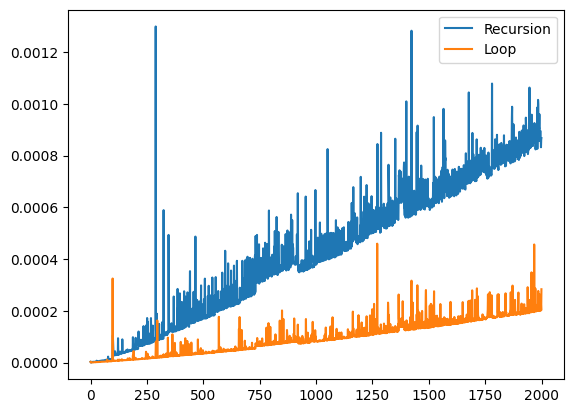

In [146]:
    recursion_history = []
    loop_history = []

    N = 2000 # Change here
    N_list = [i for i in range(N)]
    for i in range(N):

        recursion_time, _  =  fibonacci_recursion(i)
        loop_time, _  =  fibonacci_loop(i)

        recursion_history.append(recursion_time)
        loop_history.append(loop_time)


    plt.plot(N_list,recursion_history, label = 'Recursion'  )
    plt.plot(N_list, loop_history, label ='Loop')
    plt.legend()
    plt.show()
    

Về tổng quan, thời gian thực của vòng lặp nhanh hơn so với giải thuật đệ quy, cụ thể tại mốc sinh ra 2000 phần tử: vòng lặp chỉ cần 1e-4 (s) trong khi đệ quy cần 8e-4 (s).

3. Kết luận về khả năng chạy của 2 thuật toán (N lớn nhất mà thuật toán có 
thể xử lý được với thời gian thực thi được cho trước). 

In [131]:
 
def loop_with_defined_time(defined_time):
    fibonacci_list = [0,1]
        
    fib1 = 0
    fib2 = 1
    
    end_time = time.time() + defined_time
    while time.time() < end_time :
        fib_i = fib1 + fib2
        fib1, fib2 = fib2, fib_i
        fibonacci_list.append(fib_i)
    
    return len(fibonacci_list)
# %%

In [132]:
def recursion_with_time(end_time ,fibo_list):
    if time.time() > end_time:
        return fibo_list
    else:
        fibo_list.append(fibo_list[len(fibo_list)-1] + fibo_list[len(fibo_list)-2])
        return recursion_with_time(end_time,fibo_list)

In [133]:
def recursion_with_defined_time(defined_time):
    recursion_fibonacci_list = [0,1]
        
    fib1 = 0
    fib2 = 1
    
    end_time = time.time() + defined_time
    
    recursion_fibonacci_list = recursion_with_time(end_time,recursion_fibonacci_list )
    
    return len(recursion_fibonacci_list)

In [140]:
avg_loop_list = 0
avg_recursion_list = 0
for i in range(10):
    avg_loop_list += loop_with_defined_time(1e-3)
    avg_recursion_list += recursion_with_defined_time(1e-3)

print(f'In {1e-3} second')
print(f"Loop method can process {round(avg_loop_list/10)} (Max N) while that of Recursion method is {round(avg_recursion_list/10)} (Max N) ")

In 0.001 second
Loop method can process 3892 (Max N) while that of Recursion method is 1888 (Max N) 


Test 2 thuật toán trong 1e-3 (s), không thể tăng thêm vì Ngoại lệ đệ quy (Recursion Error) xuất hiện thì: 
- Vòng lặp xử lý được 3892 phần tử
- Đệ quy xử lý được 1888 phần tử 
=> Vòng lặp xử lý nhanh gấp đôi đệ quy